# glex Complexity Benchmark

Empirically validates `O(T · 2^D · Σ_{i=0}^{s} C(F,i) · n)` complexity,
sweeping **F** (features per tree) for each interaction order **s = 1, 2, D**.

**Runtime → Change runtime type → R** before running.

### Design notes
* `F` is measured as the **mean number of distinct split-features per tree**,
  which is what drives glex cost (each tree is processed independently).
* A tree of depth D has at most `2^D - 1` internal nodes, so per-tree F is
  capped by D, not by the dataset width.  We use **D = 6** so F can range up
  to ~50 before saturating, giving a wide enough range for all three s values.
* For **s = 1** the number of subsets is tiny (≈ F), so we need large `n_explain`
  to get measurable wall-clock times.  For **s = D = 6** the subset count
  explodes (Σ C(F,i) ≈ F^6 / 720), so we keep F small and n moderate.

In [1]:
install.packages(c("xgboost", "ggplot2", "dplyr", "tidyr", "remotes"),
                 repos = "https://cloud.r-project.org", quiet = TRUE)
remotes::install_github("PlantedML/glex", quiet = TRUE)

cat("xgboost:", as.character(packageVersion("xgboost")), "\n")
cat("glex   :", as.character(packageVersion("glex")),    "\n")

Installing 13 packages: rlang, glue, cli, vctrs, cpp11, S7, iterators, backports, Rcpp, scico, foreach, data.table, checkmate



xgboost: 3.2.1.1 
glex   : 0.5.2 


In [2]:
library(xgboost)
library(glex)
library(ggplot2)
library(dplyr)
library(tidyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Helper functions

In [3]:
# Data where all F features are truly informative: main effects + consecutive
# pairwise interactions.  XGBoost has equal incentive to split on every feature.
generate_data <- function(n, F, seed = 1) {
  set.seed(seed)
  X <- matrix(rnorm(n * F), nrow = n, ncol = F)
  colnames(X) <- paste0("x", seq_len(F))
  y <- rowSums(X)
  for (j in seq_len(F - 1))
    y <- y + X[, j] * X[, j + 1L]
  y <- y + rnorm(n, sd = 0.1)
  list(X = X, y = y)
}

# Mean number of DISTINCT split features per tree (this is the F that drives
# glex cost, because each tree is explained independently).
mean_F_per_tree <- function(model) {
  trees <- xgb.model.dt.tree(model = model)
  trees %>%
    filter(Feature != "Leaf") %>%
    group_by(Tree) %>%
    summarise(f = n_distinct(Feature), .groups = "drop") %>%
    pull(f) %>%
    mean()
}

# Theoretical complexity kernel (normalised so minimum = 1 for plotting).
sum_C   <- function(F, s) sum(choose(F, 0:min(s, F)))
norm01  <- function(x) (x - min(x)) / (max(x) - min(x) + .Machine$double.eps)

# Fit log-log slope and return a label string.
loglog_slope <- function(df) {
  fit <- lm(log(time_mean) ~ log(F_mean), data = df)
  round(coef(fit)[["log(F_mean)"]], 2)
}

# Three-panel summary plot for one s-experiment.
make_plots <- function(df, s_val, D_val) {
  slope <- loglog_slope(df)
  df <- df %>% mutate(theory = sapply(F_mean, sum_C, s = s_val))

  p1 <- ggplot(df, aes(F_mean, time_mean)) +
    geom_ribbon(aes(ymin = time_mean - time_sd,
                    ymax = time_mean + time_sd), alpha = .2, fill = "steelblue") +
    geom_line(color = "steelblue", linewidth = 1) +
    geom_point(size = 3, color = "steelblue") +
    labs(title = sprintf("Runtime vs F  (s=%s, D=%d)", s_val, D_val),
         x = "Mean F per tree", y = "Time (s)") +
    theme_bw(base_size = 13)

  p2 <- ggplot(df, aes(log(F_mean), log(time_mean))) +
    geom_point(size = 3, color = "steelblue") +
    geom_smooth(method = "lm", se = TRUE, color = "tomato", linetype = "dashed") +
    labs(title = sprintf("Log-log  (s=%s, D=%d)", s_val, D_val),
         subtitle = sprintf("Fitted slope = %.2f   expected ≈ %s", slope, s_val),
         x = "log(F)", y = "log(time)") +
    theme_bw(base_size = 13)

  overlay <- df %>%
    transmute(F_mean,
              `Observed time`   = norm01(time_mean),
              `Σ C(F,i), i=0…s` = norm01(theory)) %>%
    pivot_longer(-F_mean, names_to = "series", values_to = "val")

  p3 <- ggplot(overlay, aes(F_mean, val, color = series, linetype = series)) +
    geom_line(linewidth = 1) + geom_point(size = 2.5) +
    scale_color_manual(values   = c("black", "tomato")) +
    scale_linetype_manual(values = c("solid", "dashed")) +
    labs(title = sprintf("Observed vs theory  (s=%s, D=%d)", s_val, D_val),
         x = "Mean F per tree", y = "Normalised value",
         color = "", linetype = "") +
    theme_bw(base_size = 13) + theme(legend.position = "bottom")

  list(p1 = p1, p2 = p2, p3 = p3, slope = slope)
}

# Generic benchmark runner.
# n_explain is clamped to nrow(X) so it can never exceed the generated data.
run_benchmark <- function(F_values, D, T_trees, n_train, n_explain,
                           max_interaction, n_reps = 3) {
  out <- vector("list", length(F_values) * n_reps)
  idx <- 1L
  for (F in F_values) {
    cat(sprintf("  F=%2d ", F))
    for (rep in seq_len(n_reps)) {
      dat    <- generate_data(n_train, F, seed = rep * 1000 + F)
      dtrain <- xgb.DMatrix(dat$X, label = dat$y)
      model  <- xgb.train(
        params  = list(max_depth = D, eta = 0.3,
                       objective = "reg:squarederror",
                       subsample = 1, colsample_bytree = 1,
                       min_child_weight = 1),
        data    = dtrain, nrounds = T_trees, verbose = 0)
      F_mean   <- mean_F_per_tree(model)
      n_actual <- min(n_explain, nrow(dat$X))   # guard against n_explain > n_train
      Xexp     <- dat$X[seq_len(n_actual), , drop = FALSE]
      t0 <- proc.time()[["elapsed"]]
      glex(model, as.data.frame(Xexp), max_interaction = max_interaction)
      t1 <- proc.time()[["elapsed"]]
      out[[idx]] <- data.frame(F = F, F_mean = F_mean,
                                time_sec = t1 - t0, rep = rep)
      idx <- idx + 1L
      cat(".")
    }
    cat("\n")
  }
  raw <- do.call(rbind, out)
  raw %>%
    group_by(F, F_mean) %>%
    summarise(time_mean = mean(time_sec), time_sd = sd(time_sec), .groups = "drop")
}

## Global fixed parameters

In [4]:
D      <- 6     # tree depth — allows per-tree F up to ~50 before saturating
T_TREES <- 20   # number of boosting rounds
N_REPS  <- 3    # repetitions per (F, s) combination
N_TRAIN <- 10000 # must be ≥ max(N_EXP_S1, N_EXP_S2, N_EXP_SD, N_EXP_S)

---
## Part 1 — s = 1  (only main effects)

With s=1, `Σ C(F,i) = 1 + F` — linear in F.  Expect log-log slope ≈ **1**.

Because the subset count is tiny (at most F+1 columns in the output matrix),
we need **large n** to get measurable wall-clock times.

In [5]:
# With D=6 each tree has ≤63 internal nodes → per-tree F ≤ ~40 in practice.
# For s=1 the computation is very cheap, so we push F and n high.
F_s1     <- c(3, 5, 8, 12, 17, 22, 28, 35)
N_EXP_S1 <- 8000   # large n to get measurable times for cheap s=1

cat("=== s=1 benchmark ===\n")
df_s1 <- run_benchmark(F_s1, D = D, T_trees = T_TREES,
                        n_train = N_TRAIN, n_explain = N_EXP_S1,
                        max_interaction = 1, n_reps = N_REPS)
print(df_s1)

=== s=1 benchmark ===
  F= 3 ...
  F= 5 ...
  F= 8 ...
  F=12 ...
  F=17 ...
  F=22 ...
  F=28 ...
  F=35 ...
# A tibble: 15 × 4
       F F_mean time_mean time_sd
   <dbl>  <dbl>     <dbl>   <dbl>
 1     3    3       0.698  0.143 
 2     5    5       1.02   0.132 
 3     8    8       1.65   0.0280
 4    12   11.9     2.18   0.130 
 5    17   16.1     3.13   0.0445
 6    17   16.6     3.17  NA     
 7    22   20.0     3.10  NA     
 8    22   20.2     3.32  NA     
 9    22   20.8     4.45  NA     
10    28   24.1     3.81  NA     
11    28   24.4     3.83  NA     
12    28   25.4     3.94  NA     
13    35   28.4     4.76  NA     
14    35   29.0     5.01  NA     
15    35   29.8     5.12  NA     


Warning message:
“Removed 10 rows containing missing values or values outside the scale range
(`geom_ribbon()`).”
`geom_smooth()` using formula = 'y ~ x'


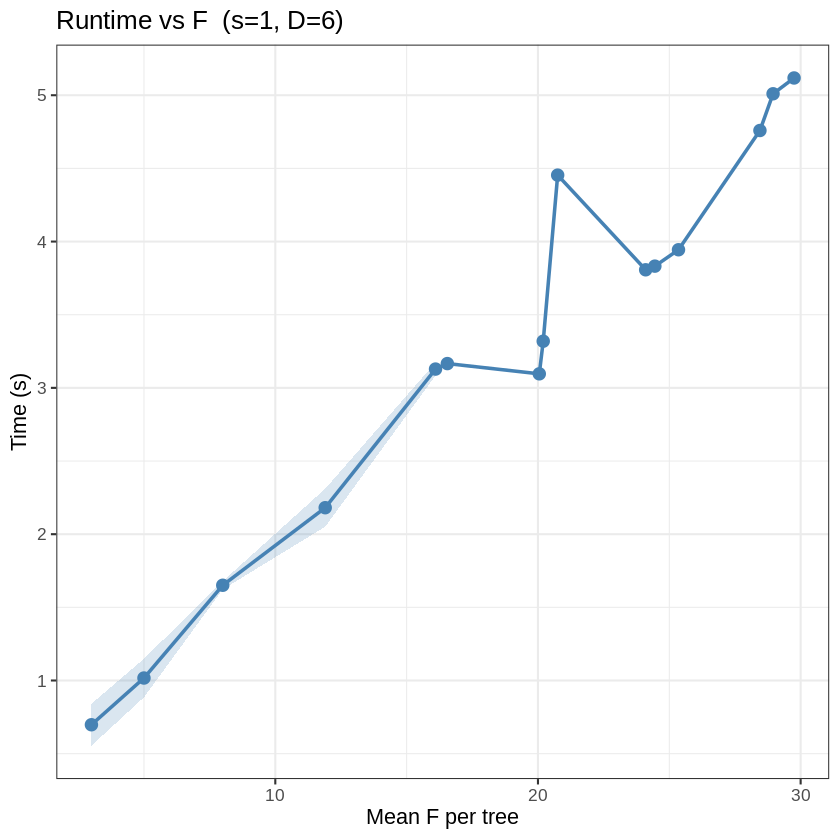

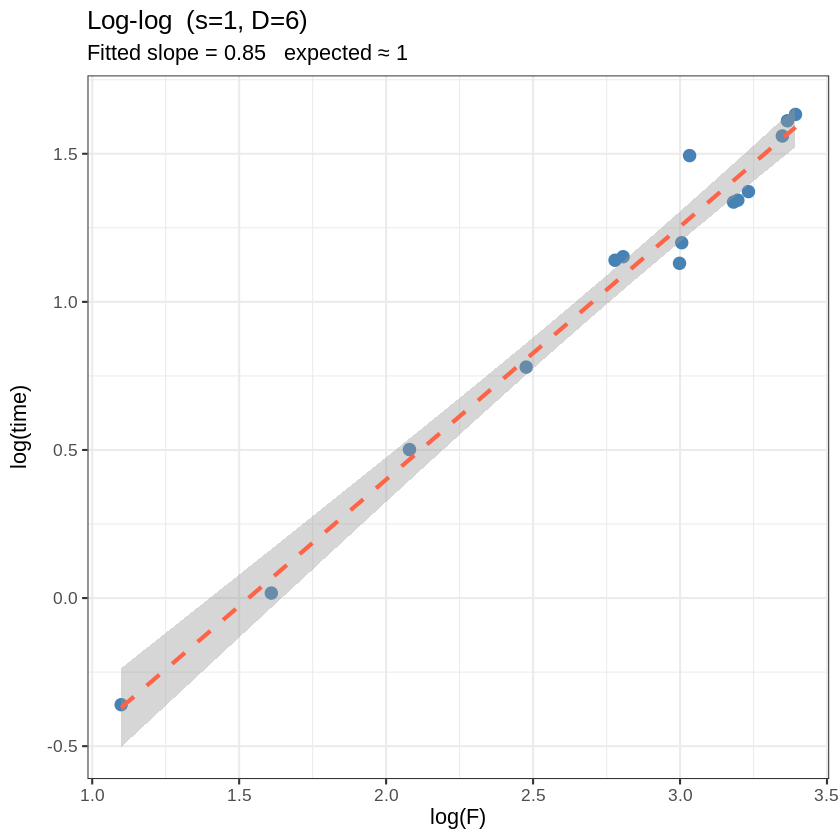


Log-log slope for s=1: 0.85  (expected ≈ 1)


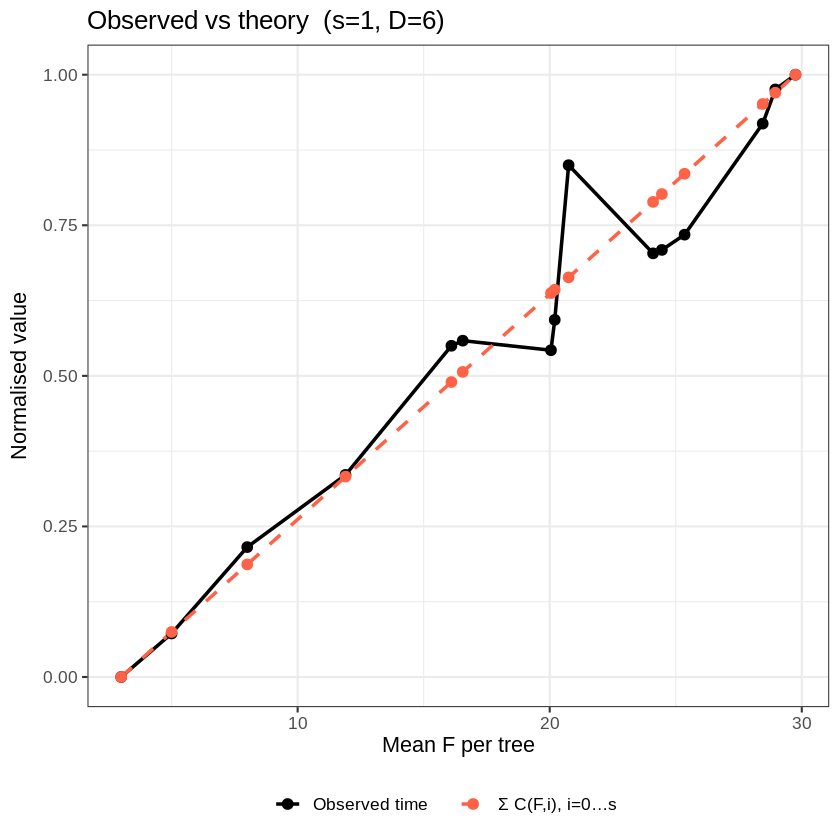

In [6]:
res_s1 <- make_plots(df_s1, s_val = 1, D_val = D)
print(res_s1$p1)
print(res_s1$p2)
print(res_s1$p3)
cat(sprintf("\nLog-log slope for s=1: %.2f  (expected ≈ 1)\n", res_s1$slope))

---
## Part 2 — s = 2  (up to pairwise interactions)

With s=2, `Σ C(F,i) = 1 + F + F(F-1)/2` — quadratic in F.  Expect log-log slope ≈ **2**.

Subset count grows faster, so we reduce F range and n slightly.

In [7]:
F_s2     <- c(3, 5, 8, 12, 17, 22, 28)
N_EXP_S2 <- 4000

cat("=== s=2 benchmark ===\n")
df_s2 <- run_benchmark(F_s2, D = D, T_trees = T_TREES,
                        n_train = N_TRAIN, n_explain = N_EXP_S2,
                        max_interaction = 2, n_reps = N_REPS)
print(df_s2)

=== s=2 benchmark ===
  F= 3 ...
  F= 5 ...
  F= 8 ...
  F=12 ...
  F=17 ...
  F=22 ...
  F=28 ...
# A tibble: 12 × 4
       F F_mean time_mean time_sd
   <dbl>  <dbl>     <dbl>   <dbl>
 1     3    3       0.533   0.191
 2     5    5       0.924   0.128
 3     8    8       2.30    0.258
 4    12   11.9     6.22    1.63 
 5    17   16.1     9.24    1.08 
 6    17   16.6    11.7    NA    
 7    22   20.0    16.5    NA    
 8    22   20.2    15.7    NA    
 9    22   20.8    16.5    NA    
10    28   24.1    18.0    NA    
11    28   24.4    18.1    NA    
12    28   25.4    18.7    NA    


Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_ribbon()`).”
`geom_smooth()` using formula = 'y ~ x'


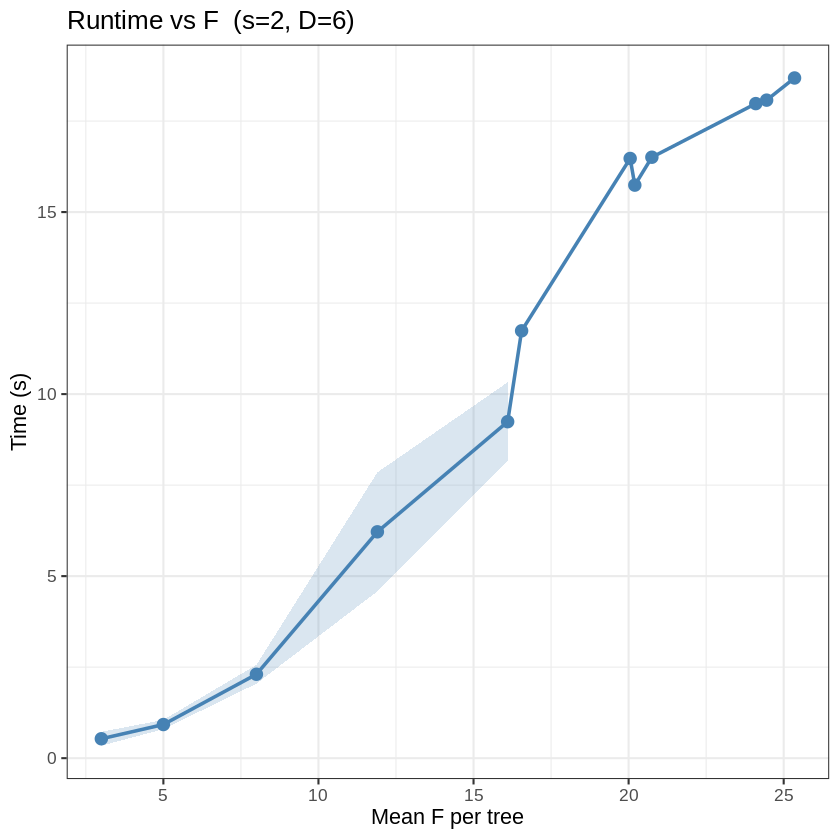

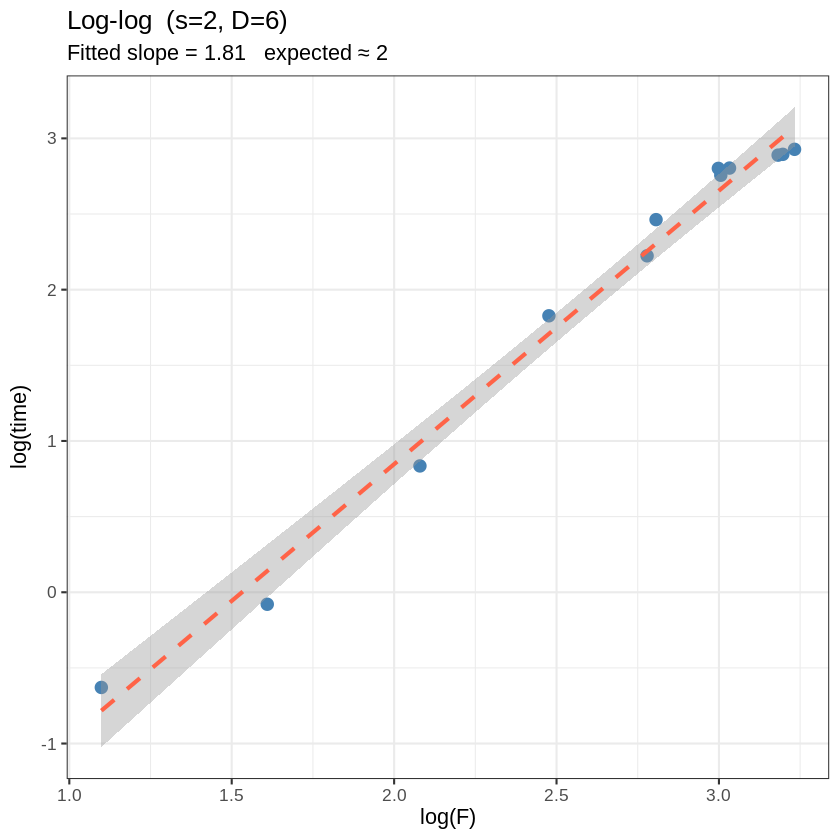


Log-log slope for s=2: 1.81  (expected ≈ 2)


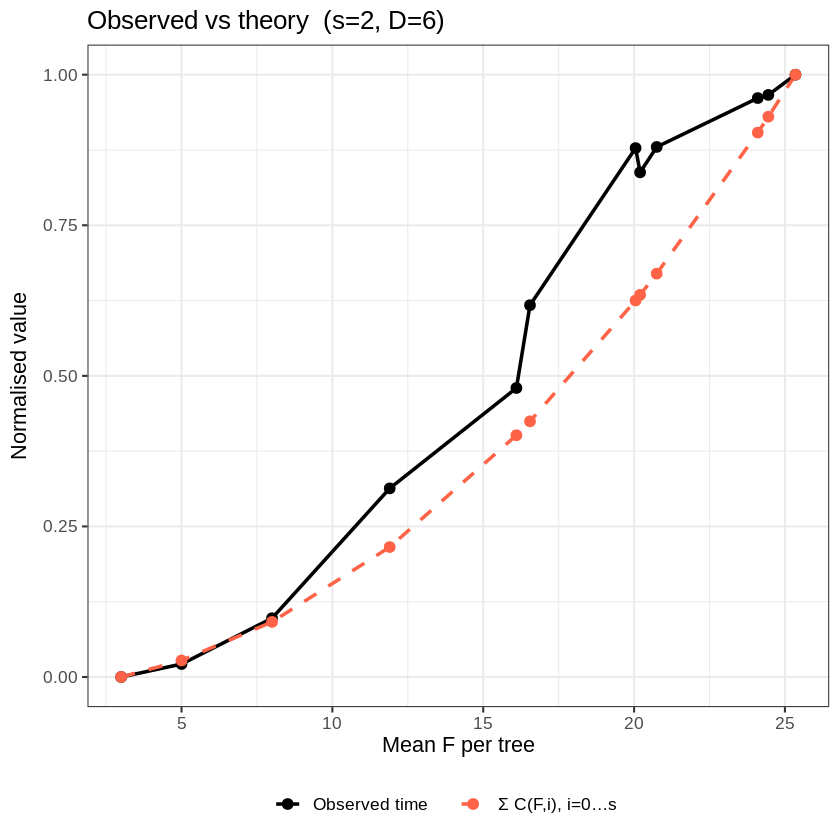

In [8]:
res_s2 <- make_plots(df_s2, s_val = 2, D_val = D)
print(res_s2$p1)
print(res_s2$p2)
print(res_s2$p3)
cat(sprintf("\nLog-log slope for s=2: %.2f  (expected ≈ 2)\n", res_s2$slope))

---
## Part 3 — s = D (all interactions, glex default)

With s=D=6, `Σ C(F,i)` grows as ~F^6/720.  Expect log-log slope ≈ **6**.

Subset count explodes quickly — keep F small and n moderate.

In [9]:
# Per-tree F saturates around ~40 for D=6, but the subset count 2^F grows so
# fast that anything beyond F~15 will be very slow.  Stay conservative.
F_sD     <- c(3, 4, 5, 6, 7, 8, 9, 10, 11, 12)
N_EXP_SD <- 1000

cat("=== s=D=6 benchmark (all interactions) ===\n")
df_sD <- run_benchmark(F_sD, D = D, T_trees = T_TREES,
                        n_train = N_TRAIN, n_explain = N_EXP_SD,
                        max_interaction = D, n_reps = N_REPS)
print(df_sD)

=== s=D=6 benchmark (all interactions) ===
  F= 3 ...
  F= 4 ...
  F= 5 ...
  F= 6 ...
  F= 7 ...
  F= 8 ...
  F= 9 ...
  F=10 ...
  F=11 ...
  F=12 ...
# A tibble: 14 × 4
       F F_mean time_mean  time_sd
   <dbl>  <dbl>     <dbl>    <dbl>
 1     3   3        0.256  0.00839
 2     4   4        0.322  0.0126 
 3     5   5        0.433  0.0106 
 4     6   6        0.709  0.185  
 5     7   7        1.16   0.159  
 6     8   8        2.55   0.185  
 7     9   9        6.95   0.292  
 8    10   9.75    12.6   NA      
 9    10   9.9     12.9   NA      
10    10  10       15.2   NA      
11    11  10.6     20.8   NA      
12    11  10.8     21.7   NA      
13    11  11.0     20.5   NA      
14    12  11.9     31.6    0.669  


Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_ribbon()`).”
`geom_smooth()` using formula = 'y ~ x'


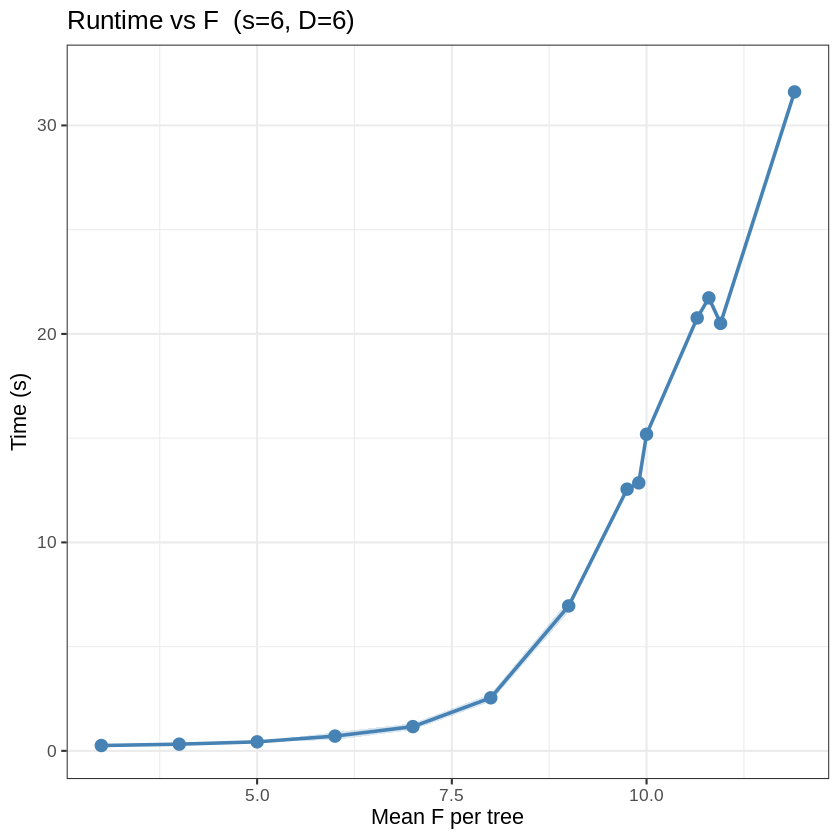

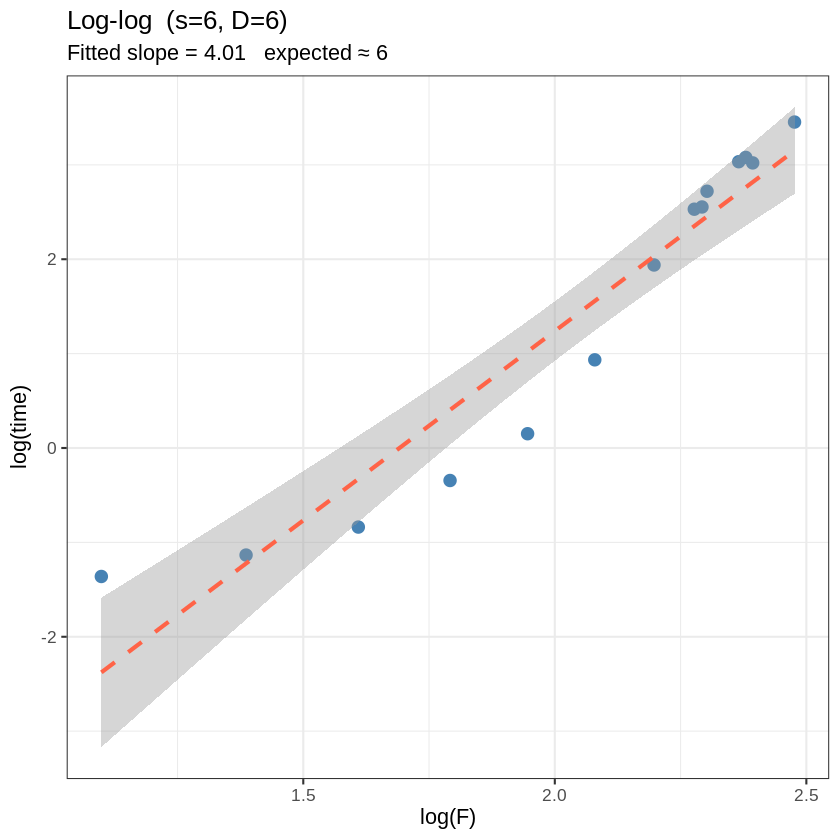


Log-log slope for s=D=6: 4.01  (expected ≈ 6)


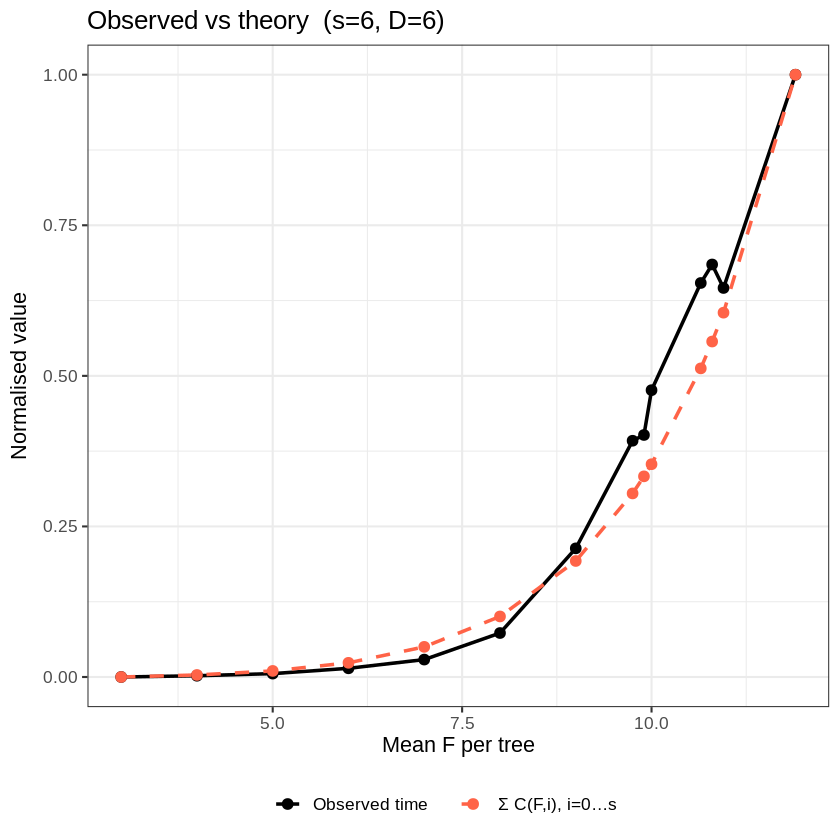

In [10]:
res_sD <- make_plots(df_sD, s_val = D, D_val = D)
print(res_sD$p1)
print(res_sD$p2)
print(res_sD$p3)
cat(sprintf("\nLog-log slope for s=D=%d: %.2f  (expected ≈ %d)\n", D, res_sD$slope, D))

---
## Part 4 — Combined log-log: all three s values on one plot

The three fitted lines should have slopes 1, 2, and 6 — directly showing how
**s controls the polynomial degree** of the F dependence.

# A tibble: 3 × 2
  s         slope
  <fct>     <dbl>
1 s = 1      0.85
2 s = 2      1.81
3 s = D = 6  4.01


`geom_smooth()` using formula = 'y ~ x'


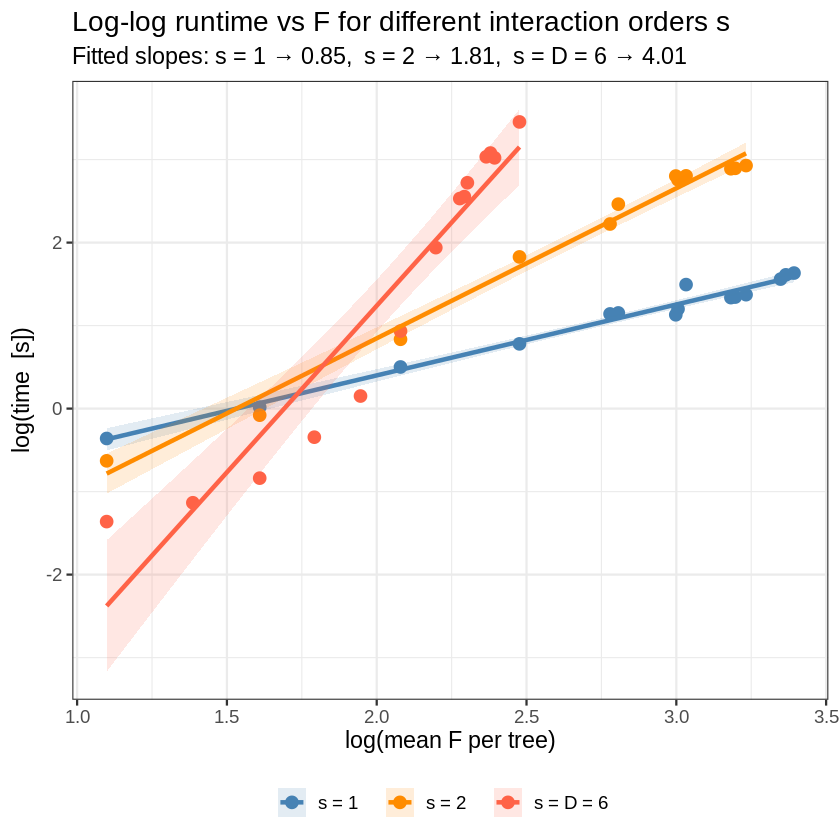

In [11]:
combined <- bind_rows(
  mutate(df_s1, s = "s = 1"),
  mutate(df_s2, s = "s = 2"),
  mutate(df_sD, s = paste0("s = D = ", D))
) %>% mutate(s = factor(s, levels = c("s = 1", "s = 2", paste0("s = D = ", D))))

# Fit slopes per group
slopes <- combined %>%
  group_by(s) %>%
  summarise(slope = round(coef(lm(log(time_mean) ~ log(F_mean)))[[2]], 2),
            .groups = "drop")
print(slopes)

ggplot(combined, aes(log(F_mean), log(time_mean), color = s, fill = s)) +
  geom_point(size = 3) +
  geom_smooth(method = "lm", se = TRUE, alpha = .15) +
  scale_color_manual(values = c("steelblue", "darkorange", "tomato")) +
  scale_fill_manual(values  = c("steelblue", "darkorange", "tomato")) +
  labs(
    title    = "Log-log runtime vs F for different interaction orders s",
    subtitle = paste("Fitted slopes:",
                     paste(paste0(slopes$s, " → ", slopes$slope), collapse = ",  ")),
    x = "log(mean F per tree)", y = "log(time  [s])",
    color = "", fill = ""
  ) +
  theme_bw(base_size = 14) +
  theme(legend.position = "bottom")

---
## Part 5 — Fix F, sweep s from 1 to D

For a fixed model, we call glex with `max_interaction = 1, 2, …, D` and
record timing.  The predicted cost is proportional to `Σ C(F, i)` for
i = 0…s, which grows steeply with s.

In [12]:
F_FIXED  <- 10      # a mid-range F that gives meaningful variation across s
N_EXP_S  <- 3000
S_VALUES <- seq_len(D)   # 1, 2, …, D

# Train once; reuse model for all s values.
set.seed(42)
dat_s    <- generate_data(N_TRAIN, F_FIXED, seed = 42)
dtrain_s <- xgb.DMatrix(dat_s$X, label = dat_s$y)
model_s  <- xgb.train(
  params  = list(max_depth = D, eta = 0.3, objective = "reg:squarederror",
                 subsample = 1, colsample_bytree = 1, min_child_weight = 1),
  data    = dtrain_s, nrounds = T_TREES, verbose = 0)

F_mean_s <- mean_F_per_tree(model_s)
Xexp_s   <- dat_s$X[seq_len(N_EXP_S), , drop = FALSE]

cat(sprintf("Model trained: F_dataset=%d, mean F per tree=%.1f, D=%d\n",
            F_FIXED, F_mean_s, D))

res_s <- vector("list", length(S_VALUES) * N_REPS)
idx   <- 1L
for (s in S_VALUES) {
  cat(sprintf("  s=%d ", s))
  for (rep in seq_len(N_REPS)) {
    t0 <- proc.time()[["elapsed"]]
    glex(model_s, as.data.frame(Xexp_s), max_interaction = s)
    t1 <- proc.time()[["elapsed"]]
    res_s[[idx]] <- data.frame(s = s, time_sec = t1 - t0, rep = rep)
    idx <- idx + 1L
    cat(".")
  }
  cat("\n")
}

df_s <- do.call(rbind, res_s) %>%
  group_by(s) %>%
  summarise(time_mean = mean(time_sec), time_sd = sd(time_sec), .groups = "drop") %>%
  mutate(theory = sapply(s, function(si) sum_C(F_mean_s, si)))

print(df_s)

Model trained: F_dataset=10, mean F per tree=9.9, D=6
  s=1 ...
  s=2 ...
  s=3 ...
  s=4 ...
  s=5 ...
  s=6 ...
# A tibble: 6 × 4
      s time_mean time_sd theory
  <int>     <dbl>   <dbl>  <dbl>
1     1     0.490 0.00917   11.0
2     2     1.36  0.143     55.5
3     3     5.58  0.679    173. 
4     4    17.2   0.464    378. 
5     5    24.2   3.72     622. 
6     6    30.2   0.489    824. 


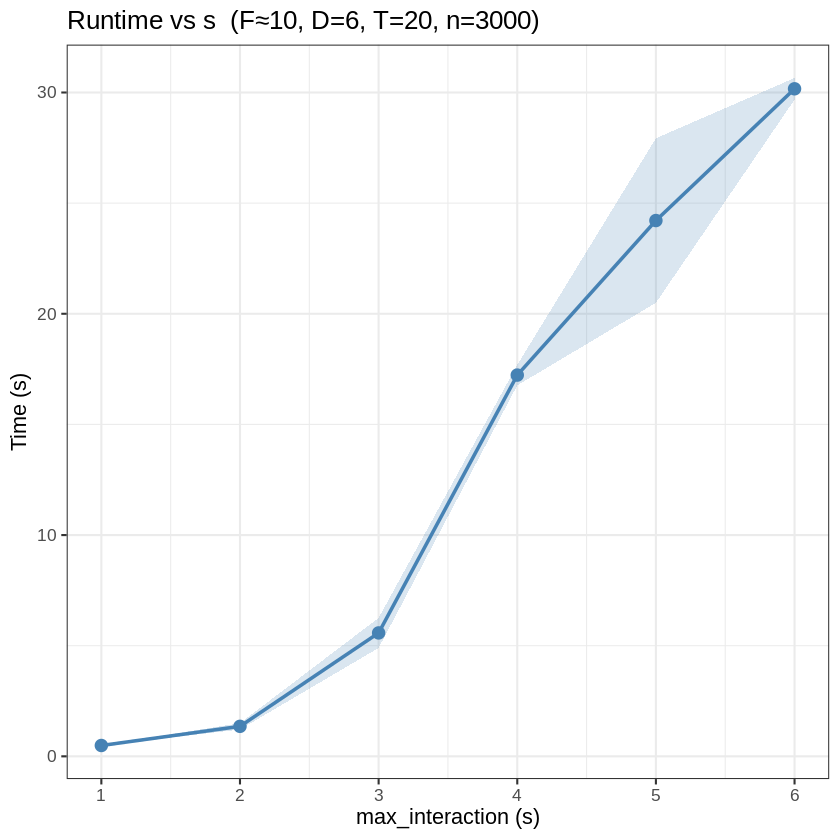

In [13]:
# Raw time vs s
ggplot(df_s, aes(s, time_mean)) +
  geom_ribbon(aes(ymin = time_mean - time_sd,
                  ymax = time_mean + time_sd), alpha = .2, fill = "steelblue") +
  geom_line(color = "steelblue", linewidth = 1) +
  geom_point(size = 3, color = "steelblue") +
  scale_x_continuous(breaks = S_VALUES) +
  labs(title = sprintf("Runtime vs s  (F≈%.0f, D=%d, T=%d, n=%d)",
                        F_mean_s, D, T_TREES, N_EXP_S),
       x = "max_interaction (s)", y = "Time (s)") +
  theme_bw(base_size = 13)

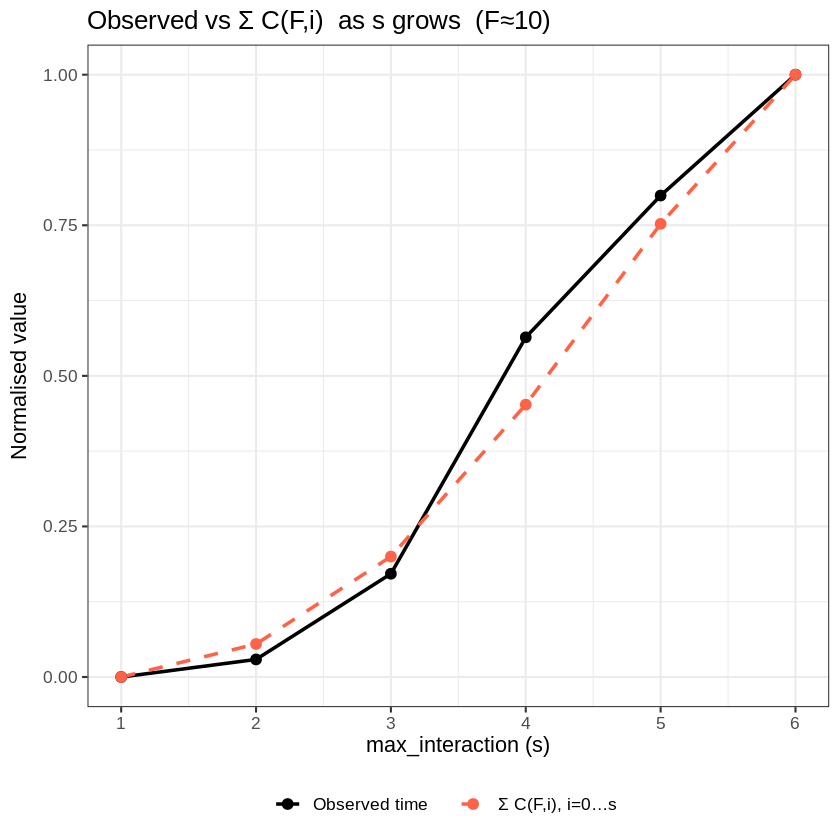

In [14]:
# Overlay observed vs Σ C(F, i)
df_s %>%
  transmute(s,
            `Observed time`   = norm01(time_mean),
            `Σ C(F,i), i=0…s` = norm01(theory)) %>%
  pivot_longer(-s, names_to = "series", values_to = "val") %>%
  ggplot(aes(s, val, color = series, linetype = series)) +
  geom_line(linewidth = 1) + geom_point(size = 2.5) +
  scale_color_manual(values   = c("black", "tomato")) +
  scale_linetype_manual(values = c("solid", "dashed")) +
  scale_x_continuous(breaks = S_VALUES) +
  labs(title = sprintf("Observed vs Σ C(F,i)  as s grows  (F≈%.0f)", F_mean_s),
       x = "max_interaction (s)", y = "Normalised value",
       color = "", linetype = "") +
  theme_bw(base_size = 13) + theme(legend.position = "bottom")